# Actividad. Perceptrón de para obtener la relación velocidad - altura

<table>
    <head>  
        <tr>
			<th colspan="2">Caracteristicas</th>
			<th>Resultado Esperado</th>
        </tr> 
        <tr>
			<th>Altura</th>
			<th>velocidad</th>
			<th>Aceleración</th>
        </tr>
    </head>
    <body>  
        <tr>
			<td style="text-align:center">0</td>
			<td style="text-align:center">0</td>
			<td style="text-align:center">350</td>
        </tr>
        <tr>
			<td style="text-align:center">0</td>
			<td style="text-align:center">1</td>
			<td style="text-align:center">200</td>
        </tr>
        <tr>
			<td style="text-align:center">1</td>
			<td style="text-align:center">0</td>
			<td style="text-align:center">200</td>
        </tr>
        <tr>
			<td style="text-align:center">1</td>
			<td style="text-align:center">1</td>
			<td style="text-align:center">50</td>
        </tr>
    </body>
</table>

In [12]:
# Definiendo la función a utilizar en el perceptrón

# Importando las librerías a utilizar
import numpy as np

# Definición de la función Relu
#   La salida es el máximo entre 0 y la suma ponderada
def relu( sumaPonderada ):
    return max( 0, sumaPonderada )


===== ÉPOCA 1 =====
x1  x2   target   salida   error
0   0      350        [0.54426995]        [349.45573005]
1   0      200        [315.4471732]        [-115.4471732]
0   1      200        [211.49408532]        [-11.49408532]
1   1      50        [87.29502207]        [-37.29502207]
Errores totales en la época: [513.69201064]
Pesos Finales: [-137.07522954  -43.56808244]
Bias Finales: [167.24177446]

===== ÉPOCA 2 =====
x1  x2   target   salida   error
0   0      350        [167.24177446]        [182.75822554]
1   0      200        [194.64894791]        [5.35105209]
0   1      200        [292.97204189]        [-92.97204189]
1   1      50        0        50
Errores totales en la época: [331.08131952]
Pesos Finales: [-87.25928266 -82.24292014]
Bias Finales: [297.86528663]

===== ÉPOCA 3 =====
x1  x2   target   salida   error
0   0      350        [297.86528663]        [52.13471337]
1   0      200        [257.52724601]        [-57.52724601]
0   1      200        [210.76908712]        [-10

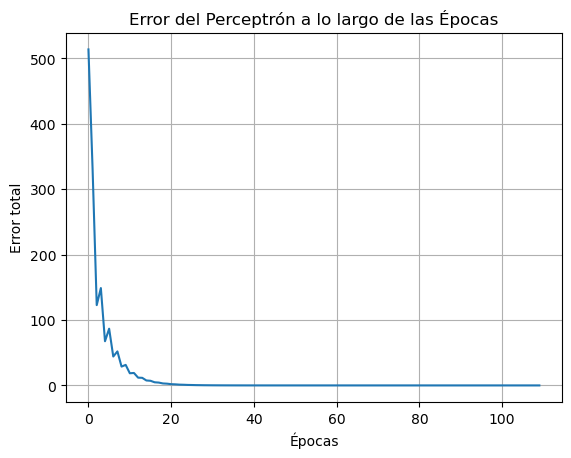

In [20]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

# Definición de las entradas de la tabla de verdad
entradas = np.array( [ [ 0, 0 ], [ 1, 0 ], [ 0, 1 ], [ 1, 1 ] ] )

# Definión de los resultados esperados del procesamiento de la información por el perceptrón
resultadoEsperado = np.array( [ 350, 200, 200, 50 ] )

# Definición de los pesos y el bias iniciales
pesos = np.random.rand(2)
bias = np.random.rand(1)

# Definición del learning_rate y las epocas
learning_rate = 0.9
epocas = 110

# Inicializando los arreglos donde se almacenaran los valores y las epocas correspondientes
errores_x_epoca = []
epocas_tiempo = []

# Entrenamiento del perceptrón
for epoca in range(epocas):
    
    error_epoca = 0
    
    # Se imprime el cabecero de la información por epoca
    print(f"\n===== ÉPOCA { epoca + 1 } =====")
    print("x1  x2   target   salida   error")

    for i in range(len(entradas)):
        
        # Obteniendo el valor de las entradas y el valor esperado 
        x = entradas[ i ]
        resultado_esperado = resultadoEsperado[ i ]
        
        # Cálculo de la suma ponderada
        sumaPonderada = np.dot(entradas[i], pesos) + bias
        
        # Cálculo de la salida utilizando la función Relu
        salida = relu(sumaPonderada)
        
        # Cálculo del error
        error = resultadoEsperado[i] - salida
        
        # Actualización de los pesos y el bias utilizando la regla de aprendizaje del perceptrón
        pesos = pesos + learning_rate * error * entradas[i]
        bias = bias + learning_rate * error
        # Imprimiendo los valores obtenidos con los esperados
        print(f"{ x[ 0 ]}   { x[ 1 ] }      { resultado_esperado }        { salida }        { error }")
        # Acumulación del error para la época actual
        error_epoca += abs(error)
        
    print(f'Errores totales en la época: { error_epoca }')
    print(f'Pesos Finales: { pesos }')
    print(f'Bias Finales: { bias }')
    # Almacenamiento del error total de la época y el número de época
    errores_x_epoca.append(error_epoca)
    epocas_tiempo.append(epoca)
# Visualización del error a lo largo de las épocas
plt.plot(epocas_tiempo, errores_x_epoca)
plt.xlabel('Épocas')
plt.ylabel('Error total')
plt.title('Error del Perceptrón a lo largo de las Épocas')
plt.grid()
plt.show()

